In [121]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense,Flatten,Conv2D
import matplotlib.pyplot as plt

In [122]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# === CONFIG ===
image_size = (32, 32)
batch_size = 32

# === LOAD DATA ===
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "Project/Image/train",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='sparse'  # use 'categorical' if one-hot labels
)

test_generator = test_datagen.flow_from_directory(
    "Project/Image/test",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='sparse'
)
val_generator = test_datagen.flow_from_directory(
    "Project/Image/val",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='sparse'
)


Found 800 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [123]:


num_classes = 2

inputs = Input(shape=(32, 32, 3))  # RGB input
x = Conv2D(8, (3, 3), activation='relu')(inputs)
x = Conv2D(8, (3, 3), activation='relu')(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 30, 30, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 28, 28, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,377,066 (12.88 MB)

 Trainable params: 3,377,066 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

In [124]:
history = model.fit(train_generator, epochs=5,validation_data=val_generator)

loss, accuracy = model.evaluate(test_generator)
print(f"loss={loss}")
print(f"accuracy={accuracy}")





Epoch 1/5


/home/apd/code/CSE_Lab/CSE_4_1/myenv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.7125 - loss: 0.5340 - val_accuracy: 0.9000 - val_loss: 0.2818
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8725 - loss: 0.2907 - val_accuracy: 0.7100 - val_loss: 0.4891
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8975 - loss: 0.2333 - val_accuracy: 0.9600 - val_loss: 0.1092
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9712 - loss: 0.0728 - val_accuracy: 0.9300 - val_loss: 0.1932
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9812 - loss: 0.0454 - val_accuracy: 0.9700 - val_loss: 0.1068
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9700 - loss: 0.0573
loss=0.057345446199178696
accuracy=0.9700000286102295


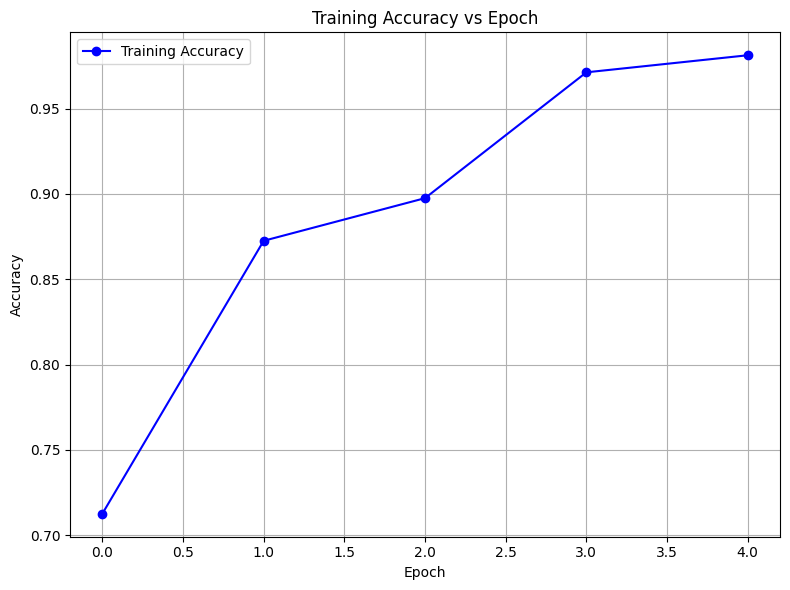

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='blue')
plt.title('Training Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


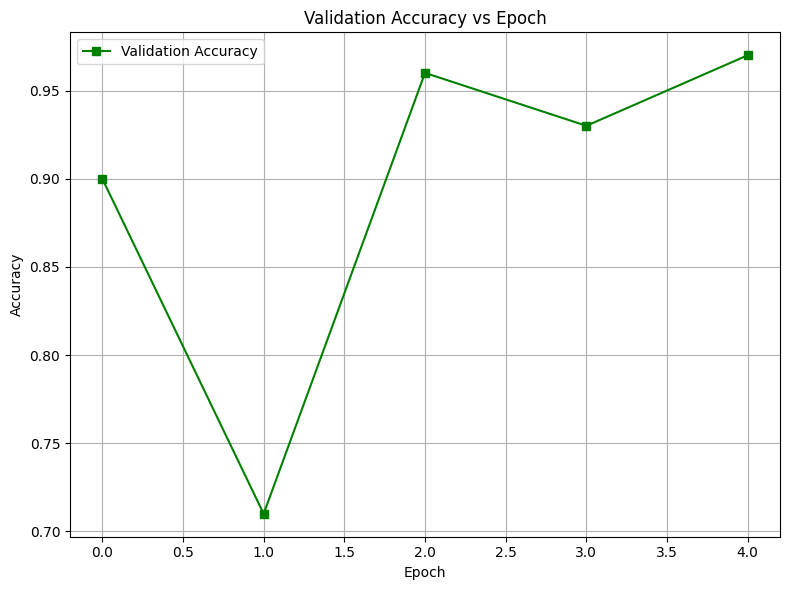

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='green')
plt.title('Validation Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


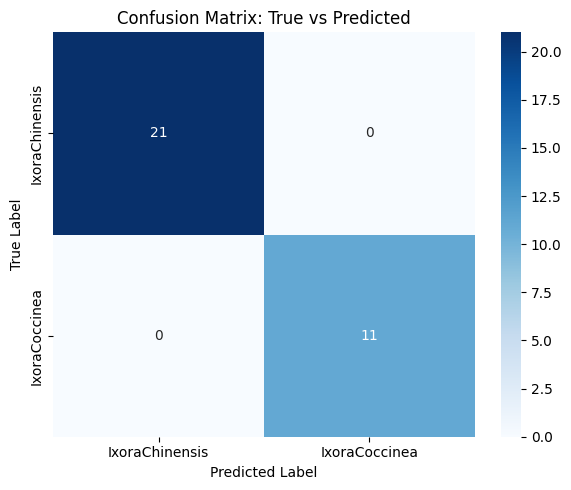

In [127]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === GET A BATCH OF TEST IMAGES ===
test_images, test_labels = next(test_generator)
pred_probs = model.predict(test_images)
pred_labels = np.argmax(pred_probs, axis=1)

# === CONFUSION MATRIX ===
cm = confusion_matrix(test_labels, pred_labels)

# === CLASS NAMES ===
class_names = list(test_generator.class_indices.keys())

# === PLOT CONFUSION MATRIX ===
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: True vs Predicted')
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


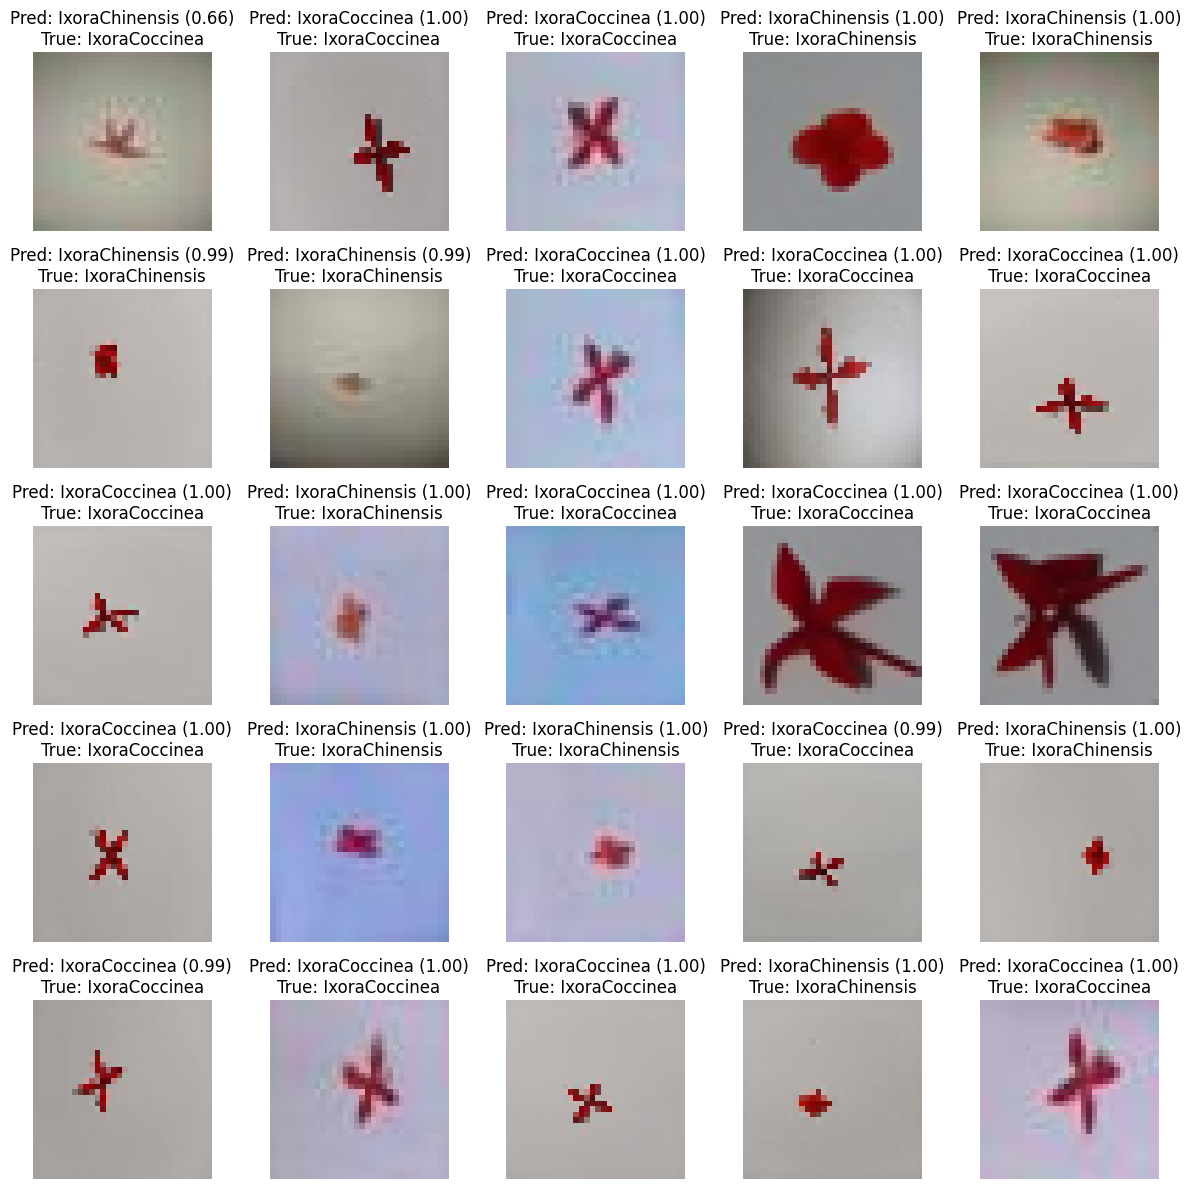

In [128]:
import matplotlib.pyplot as plt
import numpy as np

# === GET A BATCH OF TEST IMAGES ===
test_images, test_labels = next(test_generator)  # one batch of test data
pred_probs = model.predict(test_images)          # predict probabilities
pred_labels = np.argmax(pred_probs, axis=1)      # get predicted class indices

# === GET CLASS LABELS FROM GENERATOR ===
class_names = list(test_generator.class_indices.keys())

# === PLOT FIRST 25 IMAGES WITH PREDICTIONS AND CONFIDENCE ===
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    img = test_images[i]
    true_label = int(test_labels[i])
    pred_label = pred_labels[i]
    confidence = pred_probs[i][pred_label]  # confidence of predicted class
    
    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred_label]} ({confidence:.2f})\nTrue: {class_names[true_label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
